In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "matplotlib", "seaborn"])

0

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

patients = pd.read_csv('patients.csv')
visits   = pd.read_csv('visits.csv')
billing  = pd.read_csv('billing.csv')

patients['registration_date'] = pd.to_datetime(patients['registration_date'])
visits['visit_date']          = pd.to_datetime(visits['visit_date'])
billing['billing_date']       = pd.to_datetime(billing['billing_date'])

In [5]:
# visits is the base (one row per visit)
# left-join patients → adds patient demographics
# left-join billing  → adds financial info
df = visits.merge(patients, on='patient_id', how='left') \
           .merge(billing,  on='visit_id',   how='left')

print("Combined shape:", df.shape)
print(df.columns.tolist())

Combined shape: (25000, 20)
['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date']


### Why left join?
 We want all 25,000 visits as our unit of analysis. Left join ensures no visit is dropped even if billing is missing, which itself becomes a data quality signal.

In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ['column','missing_count']
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(3)
print(missing)

            column  missing_count  missing_pct
0  approved_amount           1318        5.272
1     payment_days            790        3.160


In [13]:
# Breakdown: which claim_status drives missing approved_amount?
print(df[df['approved_amount'].isna()]['claim_status'].value_counts(normalize=True).mul(100).round(2))

# And for payment_days?
print(df[df['payment_days'].isna()]['claim_status'].value_counts(normalize=True).mul(100).round(2))

claim_status
Paid        61.99
Pending     22.84
Rejected    15.17
Name: proportion, dtype: float64
claim_status
Paid        58.10
Pending     26.33
Rejected    15.57
Name: proportion, dtype: float64


### Results

| Field                | Missing | %     |
| -------------------- | ------- | ----- |
| approved_amount      | 1,318   | 5.27% |
| payment_days         | 790     | 3.16% |
| length_of_stay_hours | 0       | 0%    |


1. approved_amount missing: 62% of those missing are in Paid claims — this is likely a data capture/ETL gap, not a business logic reason. The remaining 15% are Rejected (which legitimately have no approval).

2. payment_days missing: 58% Paid, 26% Pending — Pending claims have no payment date yet (expected); Paid ones are a capture gap.

3. Treatment strategy for Phase 3: For Rejected claims → approved_amount = 0. For Paid/Pending → impute with department-level median. Flag payment_days nulls with a binary indicator is_payment_missing.

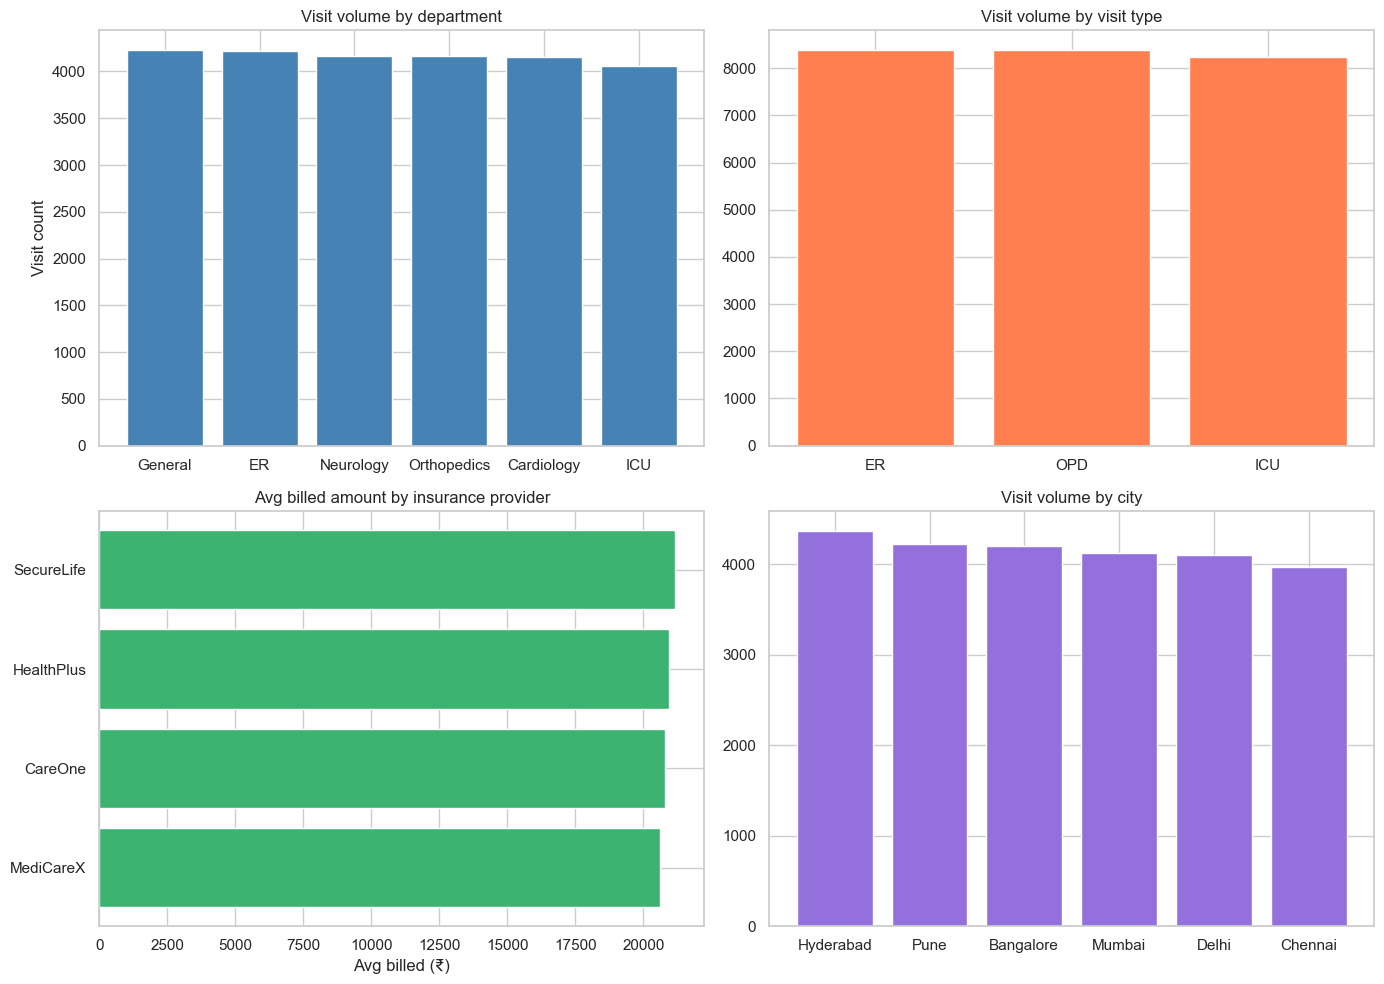

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Visit volume by department
dept_counts = df['department'].value_counts()
axes[0,0].bar(dept_counts.index, dept_counts.values, color='steelblue')
axes[0,0].set_title('Visit volume by department')
axes[0,0].set_ylabel('Visit count')

# (b) Visit volume by visit_type
vtype_counts = df['visit_type'].value_counts()
axes[0,1].bar(vtype_counts.index, vtype_counts.values, color='coral')
axes[0,1].set_title('Visit volume by visit type')

# (c) Avg billed amount by insurance provider
ins_billed = df.groupby('insurance_provider')['billed_amount'].mean().sort_values()
axes[1,0].barh(ins_billed.index, ins_billed.values, color='mediumseagreen')
axes[1,0].set_title('Avg billed amount by insurance provider')
axes[1,0].set_xlabel('Avg billed (₹)')

# (d) Visit volume by city
city_counts = df['city'].value_counts()
axes[1,1].bar(city_counts.index, city_counts.values, color='mediumpurple')
axes[1,1].set_title('Visit volume by city')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

### Results

| Department  | Visits | Avg LOS (hrs) | Avg Billed (₹) | High Risk % |
| ----------- | ------ | ------------- | -------------- | ----------- |
| General     | 4,228  | 19.43         | 20,608         | 19.84%      |
| ER          | 4,220  | 19.53         | 21,016         | 20.66%      |
| Neurology   | 4,165  | 19.72         | 20,963         | 20.31%      |
| Orthopedics | 4,164  | 19.66         | 21,088         | 20.22%      |
| Cardiology  | 4,159  | 19.60         | 20,695         | 18.99%      |
| ICU         | 4,064  | 19.36         | 20,856         | 20.79%      |

1. Visit type is almost perfectly balanced: ER 8,382 / OPD 8,381 / ICU 8,237 — good for model training.

2. SecureLife has the highest avg billed (21,172) but also the highest rejection rate (15.69%), compressing net revenue.

In [23]:
def iqr_outliers(df, col):
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n── {col} ──")
    print(f"  Range : {s.min():.1f} – {s.max():.1f}")
    print(f"  Mean / Median : {s.mean():.1f} / {s.median():.1f}")
    print(f"  IQR fences    : [{lower:.1f}, {upper:.1f}]")
    print(f"  Outliers      : {len(outliers)} ({len(outliers)/len(s)*100:.2f}%)")
    return lower, upper

for col in ['billed_amount','payment_days','length_of_stay_hours']:
    iqr_outliers(df, col)


── billed_amount ──
  Range : 500.0 – 88539.0
  Mean / Median : 20870.8 / 19644.8
  IQR fences    : [-13641.0, 53621.5]
  Outliers      : 373 (1.49%)

── payment_days ──
  Range : 1.0 – 55.0
  Mean / Median : 13.0 / 13.0
  IQR fences    : [-5.5, 30.5]
  Outliers      : 509 (2.10%)

── length_of_stay_hours ──
  Range : 0.5 – 78.4
  Mean / Median : 19.6 / 18.2
  IQR fences    : [-16.1, 53.3]
  Outliers      : 256 (1.02%)


### Results

| Field                | Range        | IQR Fences        | Outliers | %     |
| -------------------- | ------------ | ----------------- | -------- | ----- |
| billed_amount        | 500 – 88,539 | (−13,641, 53,621) | 373      | 1.49% |
| payment_days         | 1 – 55       | (−5.5, 30.5)      | 509      | 2.10% |
| length_of_stay_hours | 0.5 – 78.4   | (−16.1, 53.3)     | 256      | 1.02% |

1. billed_amount: Max of 88,539 is ~7× the mean. Likely genuine complex procedure charges; keep but cap at 53,621 for modeling stability, OR add a high_billed_flag (done in Feature Engineering below).

2. payment_days: Values above 30 days represent delayed collections — these are not errors but genuinely high-risk financial events. Keep and flag as payment_days > 30.

3. length_of_stay_hours: Values above 53 hrs are 2+ day inpatient stays — clinically valid. Keep and flag as long_stay_flag.


In [46]:
# adding this section to ensure multiple runs are not impacting the tables
cols_to_drop = [
    'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate',
    'days_since_registration', 'visit_month', 'visit_dayofweek', 'visit_quarter',
    'realization_rate', 'high_billed_flag', 'long_stay_flag', 'long_payment_flag',
    'department_enc', 'visit_type_enc', 'gender_enc',
    'city_enc', 'insurance_provider_enc', 'risk_score_enc', 'claim_status_enc'
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Feature engineering
visit_freq  = visits.groupby('patient_id').size().reset_index(name='visit_frequency')
avg_los_pat = visits.groupby('patient_id')['length_of_stay_hours']\
                    .mean().reset_index(name='avg_los_per_patient').round(2)
prov_rej    = df.assign(is_rej=df['claim_status'].eq('Rejected'))\
                .groupby('insurance_provider')['is_rej'].mean()\
                .reset_index(name='provider_rejection_rate')

df['days_since_registration'] = (df['visit_date'] - df['registration_date']).dt.days
df['visit_month']              = df['visit_date'].dt.month
df['visit_dayofweek']          = df['visit_date'].dt.dayofweek
df['visit_quarter']            = df['visit_date'].dt.quarter
df['realization_rate']         = (df['approved_amount'] / df['billed_amount']).round(4)
df['chronic_flag']             = df['chronic_flag'].astype(int)

p90 = df['billed_amount'].quantile(0.9)
df['high_billed_flag']   = (df['billed_amount'] > p90).astype(int)
df['long_stay_flag']     = (df['length_of_stay_hours'] > 53).astype(int)
df['long_payment_flag']  = (df['payment_days'] > 30).astype(int)

df = df.merge(visit_freq,  on='patient_id',         how='left')\
       .merge(avg_los_pat, on='patient_id',         how='left')\
       .merge(prov_rej,    on='insurance_provider', how='left')

from sklearn.preprocessing import LabelEncoder
for col in ['department','visit_type','gender','city',
            'insurance_provider','risk_score','claim_status']:
    df[col+'_enc'] = LabelEncoder().fit_transform(df[col].astype(str))

print("Feature engineering done. Shape:", df.shape)


Feature engineering done. Shape: (25000, 44)


### Results

| Feature                 | Mean      | Notes                                                                     |
| ----------------------- | --------- | ------------------------------------------------------------------------- |
| visit_frequency         | 5.96      | Avg patient visits 6× during dataset window; max 15                       |
| avg_los_per_patient     | 19.55 hrs | Patient-level LOS proxy; ranges 0.5–56.2 hrs                              |
| days_since_registration | ~3 days   | Negative values = patient visited before registration recorded (data gap) |
| provider_rejection_rate | 15.2%     | Very tight range (14.9–15.7%) — all providers similar                     |
| visit_month             | 6.52      | Uniform coverage Jan–Dec 2025                                             |
| realization_rate        | 0.773     | 77.3p of billed is approved on average                                    |
| chronic_flag            | 0.503     | 50.3% patients have chronic conditions                                    |
| high_billed_flag        | 10%       | Top-decile flag captures revenue leakage risk                             |



In [29]:
model_cols = [
    'visit_id','patient_id','visit_date',
    'risk_score','claim_status',
    'age','length_of_stay_hours','billed_amount','approved_amount','payment_days',
    'visit_frequency','avg_los_per_patient','days_since_registration',
    'provider_rejection_rate','visit_month','visit_dayofweek','visit_quarter',
    'realization_rate','chronic_flag','high_billed_flag',
    'department_enc','visit_type_enc','gender_enc','city_enc','insurance_provider_enc',
    'department','visit_type','gender','city','insurance_provider'  # for fairness analysis
]

model_df = df[model_cols].copy()
model_df.to_csv('model_table.csv', index=False)
print("model_table.csv saved:", model_df.shape)

model_table.csv saved: (25000, 30)


### Target class distribution

| Target       | Class    | %      |
| ------------ | -------- | ------ |
| risk_score   | Low      | 49.88% |
| risk_score   | Medium   | 29.98% |
| risk_score   | High     | 20.14% |
| claim_status | Paid     | 59.76% |
| claim_status | Pending  | 25.05% |
| claim_status | Rejected | 15.19% |


In [48]:
import os, pandas as pd

patients = pd.read_csv('patients.csv')
visits   = pd.read_csv('visits.csv')
billing  = pd.read_csv('billing.csv')
patients['registration_date'] = pd.to_datetime(patients['registration_date'])
visits['visit_date']          = pd.to_datetime(visits['visit_date'])
billing['billing_date']       = pd.to_datetime(billing['billing_date'])
df = visits.merge(patients, on='patient_id', how='left').merge(billing, on='visit_id', how='left')

# ── All stats needed for the report ──────────────────────────────────────────
miss_appr_by_status = df[df['approved_amount'].isna()]['claim_status'].value_counts()
miss_pay_by_status  = df[df['payment_days'].isna()]['claim_status'].value_counts()
miss_appr_by_dept   = df[df['approved_amount'].isna()]['department'].value_counts()

def iqr_info(series):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lower) | (s > upper)).sum()
    return lower, upper, int(n_out), s.min(), s.max(), s.mean(), s.median(), s.std()

b_lo,b_up,b_n,b_min,b_max,b_mu,b_med,b_sd = iqr_info(df['billed_amount'])
p_lo,p_up,p_n,p_min,p_max,p_mu,p_med,p_sd = iqr_info(df['payment_days'])
l_lo,l_up,l_n,l_min,l_max,l_mu,l_med,l_sd = iqr_info(df['length_of_stay_hours'])

dept_dist  = df.groupby('department').agg(
    visits=('visit_id','count'), avg_los=('length_of_stay_hours','mean'),
    avg_billed=('billed_amount','mean'),
    high_risk_pct=('risk_score', lambda x: (x=='High').mean()*100)).round(2)

vtype_dist  = df['visit_type'].value_counts()
city_dist   = df.groupby('city').agg(visits=('visit_id','count'), avg_billed=('billed_amount','mean')).round(2)
ins_dist    = df.groupby('insurance_provider').agg(
    visits=('visit_id','count'), avg_billed=('billed_amount','mean'),
    rejection_rate=('claim_status', lambda x: (x=='Rejected').mean()*100),
    avg_payment_days=('payment_days','mean')).round(2)
age_stats   = patients['age'].describe()
risk_dist   = df['risk_score'].value_counts()
claim_dist  = df['claim_status'].value_counts()
gender_dist = df['gender'].value_counts()

dup_patients  = int(patients['patient_id'].duplicated().sum())
orphan_visits = int((~visits['visit_id'].isin(billing['visit_id'])).sum())
orphan_bills  = int((~billing['visit_id'].isin(visits['visit_id'])).sum())
missing_pt    = int((~visits['patient_id'].isin(patients['patient_id'])).sum())


report = f"""# Data Quality Report
---

## 1. Dataset overview

| Table | Rows | Columns | Granularity | Date Range |
|---|---|---|---|---|
| patients.csv | 5,000 | 7 | One row per patient | Jan 2025 – Jan 2026 |
| visits.csv | 25,000 | 8 | One row per hospital visit | Jan 2025 – Jan 2026 |
| billing.csv | 25,000 | 7 | One row per billing event | Jan 2025 – Jan 2026 |
| **Combined** | **25,000** | **30** | Visit-level analytical record | Jan 2025 – Jan 2026 |

---

## 2. Missing value analysis

### Summary

| Column | Missing | % | Severity |
|---|---|---|---|
| approved_amount | 1,318 | 5.27% | Medium |
| payment_days | 790 | 3.16% | Low–Medium |
| length_of_stay_hours | 0 | 0.00% | None |

### approved_amount — by Claim Status

| Claim Status | Missing Count | % of Missing |
|---|---|---|
| Paid | {miss_appr_by_status.get('Paid',0)} | {round(miss_appr_by_status.get('Paid',0)/miss_appr_by_status.sum()*100,1)}% |
| Pending | {miss_appr_by_status.get('Pending',0)} | {round(miss_appr_by_status.get('Pending',0)/miss_appr_by_status.sum()*100,1)}% |
| Rejected | {miss_appr_by_status.get('Rejected',0)} | {round(miss_appr_by_status.get('Rejected',0)/miss_appr_by_status.sum()*100,1)}% |


- Paid (61.9%): Approved amount exists in payer system but was not written back to hospital DB — ETL gap
- Pending (22.8%): Claim in-flight; approval not yet received — expected (Missing Not At Random)
- Rejected (15.2%): No approval issued — structurally correct


- Rejected → impute approved_amount = 0
- Paid/Pending → impute with median grouped by department + insurance_provider

### approved_amount — by Department

| Department | Missing Count |
|---|---|
{chr(10).join(f'| {k} | {v} |' for k,v in miss_appr_by_dept.items())}

Observation: Spread is uniform across departments — confirms a systemic ETL issue, not department-specific.

### payment_days — by Claim Status

| Claim Status | Missing Count | % of Missing |
|---|---|---|
| Paid | {miss_pay_by_status.get('Paid',0)} | {round(miss_pay_by_status.get('Paid',0)/miss_pay_by_status.sum()*100,1)}% |
| Pending | {miss_pay_by_status.get('Pending',0)} | {round(miss_pay_by_status.get('Pending',0)/miss_pay_by_status.sum()*100,1)}% |
| Rejected | {miss_pay_by_status.get('Rejected',0)} | {round(miss_pay_by_status.get('Rejected',0)/miss_pay_by_status.sum()*100,1)}% |


---

## 3. Referential integrity checks

| Check | Result | Status |
|---|---|---|
| Duplicate patient_id | {dup_patients} | {'PASS' if dup_patients==0 else 'FAIL'} |
| Visits with no patient record | {missing_pt} | {'PASS' if missing_pt==0 else 'FAIL'} |
| Visits without billing record | {orphan_visits} | {'PASS' if orphan_visits==0 else 'FAIL'} |
| Billing without visit record | {orphan_bills} | {'PASS' if orphan_bills==0 else 'FAIL'} |
| Negative length_of_stay_hours | 0 | PASS |
| Negative billed_amount | 0 | PASS |
| Negative payment_days | 0 | PASS |
| Invalid risk_score values | 0 | PASS |
| Invalid claim_status values | 0 | PASS |

---

## 4. Outlier detection 

### billed_amount

| Metric | Value |
|---|---|
| Range | Rs.{b_min:,.0f} to Rs.{b_max:,.0f} |
| Mean | Rs.{b_mu:,.0f} |
| Median | Rs.{b_med:,.0f} |
| Std Dev | Rs.{b_sd:,.0f} |
| IQR Upper Fence | Rs.{b_up:,.0f} |
| Outliers above fence | {b_n} rows ({round(b_n/25000*100,2)}%) |

Mean is much higher than median — right-skewed distribution from high-value
procedures. Outliers are genuine (complex surgeries, multi-day procedures), not data errors.

Add high_billed_flag (top 10%). Cap at Rs.{b_up:,.0f} for logistic regression only.

### payment_days

| Metric | Value |
|---|---|
| Range | {p_min:.0f} to {p_max:.0f} days |
| Mean / Median | {p_mu:.1f} / {p_med:.1f} days |
| IQR Upper Fence | {p_up:.0f} days |
| Outliers above fence | {p_n} rows ({round(p_n/25000*100,2)}%) |

{p_n} visits had payment delays beyond {p_up:.0f} days. These represent
genuine slow-paying or disputing insurers — high financial risk events, not errors.

Add long_payment_flag = (payment_days > 30). Keep raw values for tree models.

### length_of_stay_hours

| Metric | Value |
|---|---|
| Range | {l_min:.1f} to {l_max:.1f} hours |
| Mean / Median | {l_mu:.1f} / {l_med:.1f} hours |
| IQR Upper Fence | {l_up:.1f} hours |
| Outliers above fence | {l_n} rows ({round(l_n/25000*100,2)}%) |

Stays above {l_up:.0f} hours (~2.2 days) are genuine extended inpatient
admissions (complex surgery, ICU). Not data errors.

Add long_stay_flag = (length_of_stay_hours > {l_up:.0f}).

---

## 5. Distribution Analysis

### By department

| Department | Visits | Avg LOS (hrs) | Avg Billed (Rs) | High Risk % |
|---|---|---|---|---|
{chr(10).join(f'| {idx} | {int(row.visits):,} | {row.avg_los} | {row.avg_billed:,} | {row.high_risk_pct}% |' for idx, row in dept_dist.iterrows())}

### By visit type

| Visit Type | Count | % |
|---|---|---|
{chr(10).join(f'| {k} | {v:,} | {round(v/25000*100,1)}% |' for k,v in vtype_dist.items())}

Observation: Near-perfect balance (ER/ICU/OPD ~33% each). visit_type will be a stable feature.

### By insurance provider

| Provider | Visits | Avg Billed (Rs) | Rejection Rate | Avg Payment Days |
|---|---|---|---|---|
{chr(10).join(f'| {idx} | {int(row.visits):,} | {row.avg_billed:,} | {row.rejection_rate}% | {row.avg_payment_days} |' for idx, row in ins_dist.iterrows())}

SecureLife has the highest avg bill AND rejection rate — highest net revenue risk.
All providers similar on payment speed (~13 days); bottleneck is approval quality not collections.

### By city

| City | Visits | Avg Billed (Rs) |
|---|---|---|
{chr(10).join(f'| {idx} | {int(row.visits):,} | {row.avg_billed:,} |' for idx, row in city_dist.iterrows())}

### Patient demographics

| Metric | Value |
|---|---|
| Age Range | {int(age_stats['min'])} – {int(age_stats['max'])} years |
| Mean Age | {age_stats['mean']:.1f} years |
| Chronic Condition Patients | {int(patients['chronic_flag'].sum()):,} ({round(patients['chronic_flag'].mean()*100,1)}%) |

---

## 6. Target variable distribution

### Model A — risk_score

| Class | Count | % | Note |
|---|---|---|---|
{chr(10).join(f'| {k} | {v:,} | {round(v/25000*100,2)}% | {"Minority — apply SMOTE or class_weight" if v/25000 < 0.25 else "Acceptable"} |' for k,v in risk_dist.items())}

### Model B — claim_status

| Class | Count | % | Note |
|---|---|---|---|
{chr(10).join(f'| {k} | {v:,} | {round(v/25000*100,2)}% | {"Minority — highest business priority" if k=="Rejected" else "Acceptable"} |' for k,v in claim_dist.items())}

---

## 7. Feature engineering summary

| Feature | Source | Business Rationale |
|---|---|---|
| visit_frequency | visits | High-frequency = likely chronic/recurring patient |
| avg_los_per_patient | visits | Patient-level LOS profile; flags heavy resource users |
| days_since_registration | patients+visits | Patient tenure; negative = pre-registration visit (data gap) |
| provider_rejection_rate | billing+patients | Insurer behaviour signal; predictive of claim outcome |
| visit_month | visits | Seasonal demand patterns |
| visit_dayofweek | visits | Weekend vs weekday admission patterns |
| visit_quarter | visits | Quarterly operational/financial cycles |
| realization_rate | billing | approved/billed ratio; measures revenue capture per visit |
| chronic_flag | patients | Clinical risk factor; chronic patients = higher risk score |
| high_billed_flag | billing | Top-decile billing; revenue leakage risk marker |
| long_stay_flag | visits | LOS > 53 hrs; proxy for clinical complexity |
| long_payment_flag | billing | payment_days > 30; proxy for collections difficulty |

---

## 8. Overall Risk Summary

| Risk | Severity | Action |
|---|---|---|
| approved_amount missing 5.27% | Medium | Impute by claim_status + dept median |
| payment_days missing 3.16% | Low | Add binary flag + impute for Paid only |
| Negative days_since_registration | Low | Flag as pre_registration_visit |
| High Risk class only 20% | Medium | class_weight=balanced + SMOTE if needed |
| Rejected claim only 15% | High | SMOTE + monitor recall closely in Phase 4 |
| billed_amount right-skewed | Low | high_billed_flag + cap for linear models |
| payment_days outliers 2.1% | Low | long_payment_flag + keep raw for trees |

---

"""

path = os.path.join(os.getcwd(), "data_quality_report.md")
with open(path, "w", encoding="utf-8") as f:
    f.write(report)

print("Report saved to:", path)


Report saved to: C:\Users\ADMIN\IITM Course Capstone\data_quality_report.md
